In [2]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append("../")
from xThreat import xThreat

# Import the data

In [3]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [4]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']

# Inspection of general errors

In [5]:
df_errors['xG_error_inf_norm'].describe()

count    48000.000000
mean         0.915190
std          0.180117
min          0.133333
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: xG_error_inf_norm, dtype: float64

We can see that the general maximal xG error seems to be quite large. Especially for large data sets, this is suprising. We'll look

In [6]:
df_errors.sort_values(by=['n_x', '1/sqrt(N)'], ascending=[True, True]).head(10)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.012561,0.010799,0.500000,0.022223,0.131414,1.0,1.0,192,0.0005,0.50472
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.012944,0.010130,0.500000,0.008385,0.117864,1.0,1.0,192,0.0005,0.50472
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.010126,0.011958,0.500000,0.006650,0.132075,1.0,1.0,192,0.0005,0.50472
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.017236,0.015174,0.157143,0.011811,0.133729,1.0,1.0,192,0.0005,0.50472
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.015648,0.017580,0.500000,0.012102,0.139206,1.0,1.0,192,0.0005,0.50472
5,16,12,4000000,5,5176047,0.000377,0.000295,0.006898,0.000456,0.000424,...,0.010738,0.013729,0.333333,0.027178,0.135318,1.0,1.0,192,0.0005,0.50472
6,16,12,4000000,6,5176048,0.000508,0.000248,0.007864,0.000433,0.000423,...,0.010959,0.014715,0.300000,0.007857,0.137429,1.0,1.0,192,0.0005,0.50472
7,16,12,4000000,7,5176049,0.000516,0.000312,0.007096,0.000379,0.000428,...,0.010325,0.009123,0.500000,0.012317,0.125164,1.0,1.0,192,0.0005,0.50472
8,16,12,4000000,8,5176050,0.000260,0.000174,0.009133,0.000469,0.000433,...,0.007400,0.008392,0.500000,0.010998,0.122867,1.0,1.0,192,0.0005,0.50472
9,16,12,4000000,9,5176051,0.000322,0.000225,0.011043,0.000332,0.000404,...,0.013202,0.012429,0.500000,0.007486,0.126872,1.0,1.0,192,0.0005,0.50472


# Example: small grid, many events

In [7]:
# Define the parameters to inspect
n_x = 16
n_y = 12
N = 4_000_000
random_state = 5176042
i_bootstrap = 0

# This gives (the lowest) xG error of 2/3

In [12]:
xT_true = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{n_x}-n_y{n_y}.pickle')

In [13]:
xT_true_sb_xg = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{n_x}-n_y{n_y}-sb-xg.pickle')

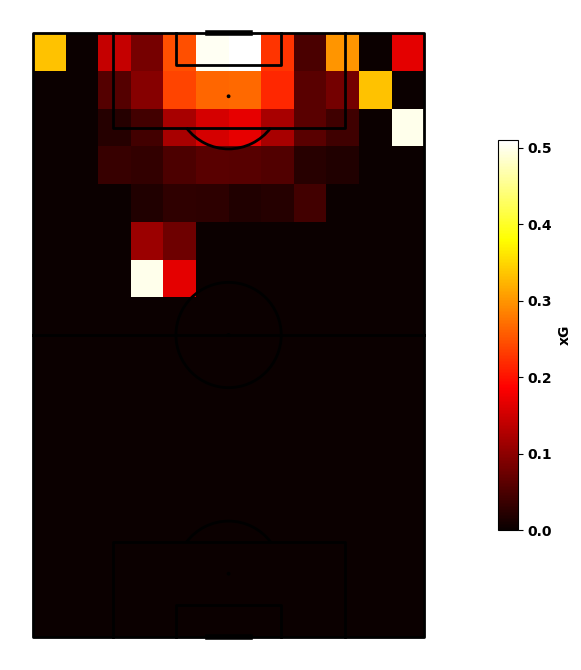

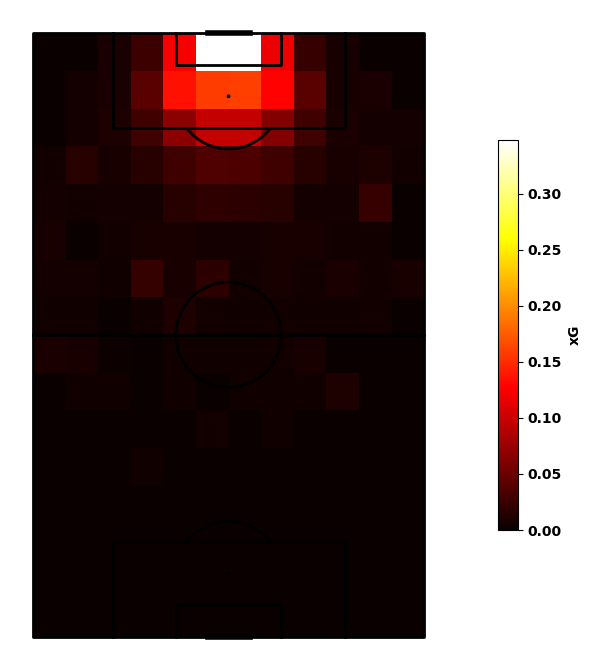

In [14]:
xT_true.plot_xG()
xT_true_sb_xg.plot_xG()

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x261f8d5a360>)

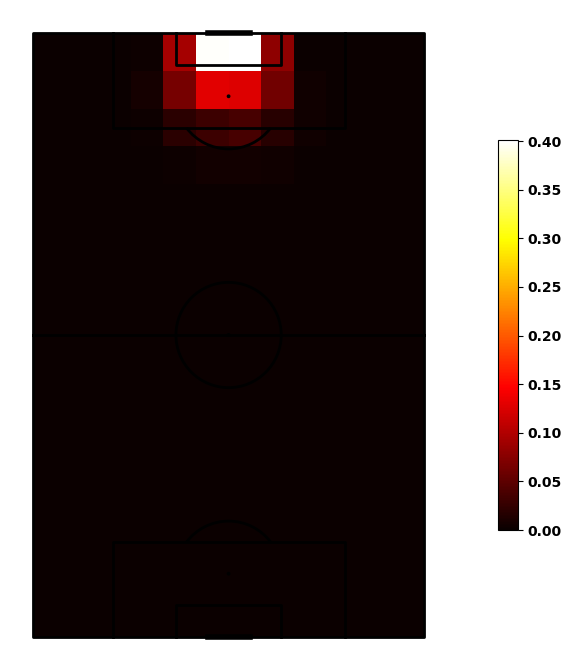

In [15]:
xT_true.plot_pitch_heatmap(xT_true.xG*xT_true.probability_shooting)

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x261f8d5aa20>)

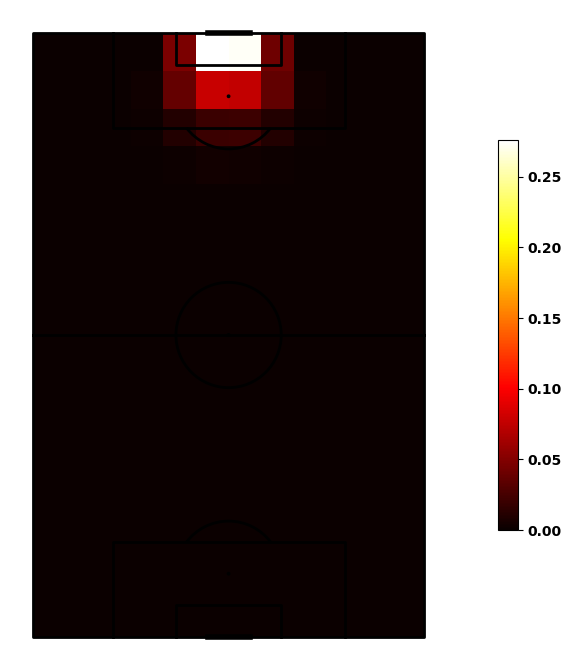

In [16]:
xT_true_sb_xg.plot_pitch_heatmap(xT_true_sb_xg.xG*xT_true_sb_xg.probability_shooting)

We can see that the xG values of the underlying model are not really accurate and look noisy. This is caused by some random shots at low-shot states and annotation bias. By multiplying with the number of shots, the effect is reduced in the end values. In practice, that is nice and helps. But for this purpose, it gives noisy data. For completeness, we'll also take a look at the same situation,but with a fine grid.

# Example: many grid points, many events

In [1]:
# Define the parameters to inspect
n_x = 64
n_y = 48
N = 4_000_000
random_state = 8704042
i_bootstrap = 0

# This gives (the lowest) xG error of 2/3

In [58]:
xT_sampled = xThreat.load_from_pickle(f'../0-model-storage/xt-N{N}-n_x{n_x}-n_y{n_y}-i_bootstrap{i_bootstrap}-random_state{random_state}.pickle')

In [59]:
xT_true = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{n_x}-n_y{n_y}.pickle')

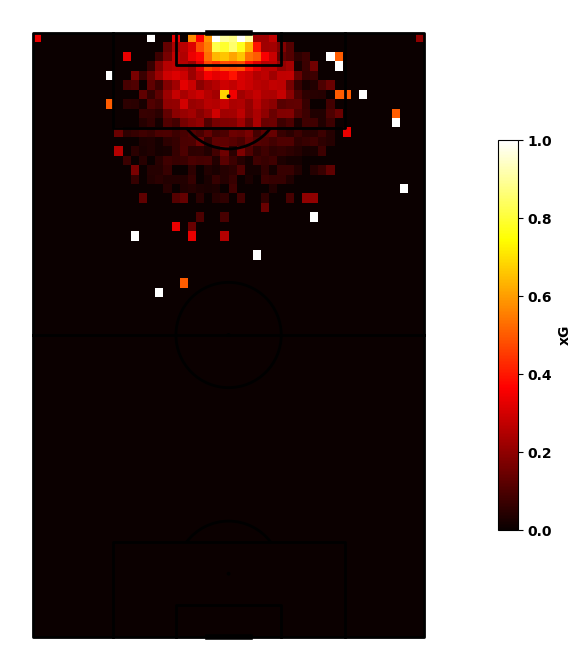

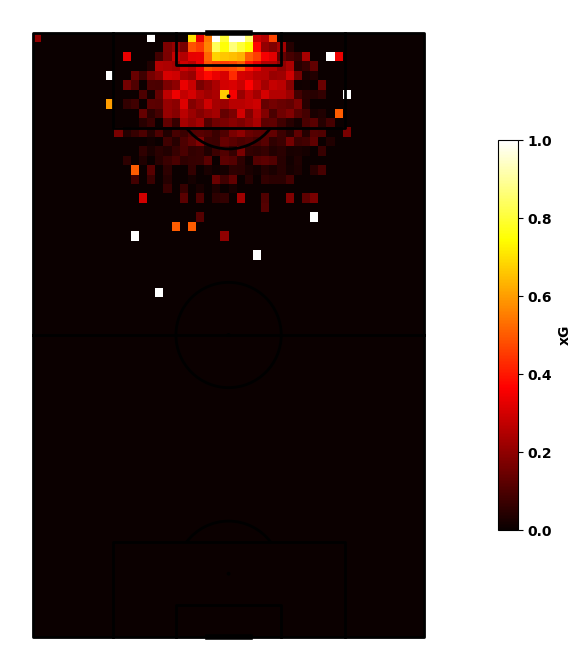

In [60]:
xT_true.plot_xG()
xT_sampled.plot_xG()

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x263a2fc0710>)

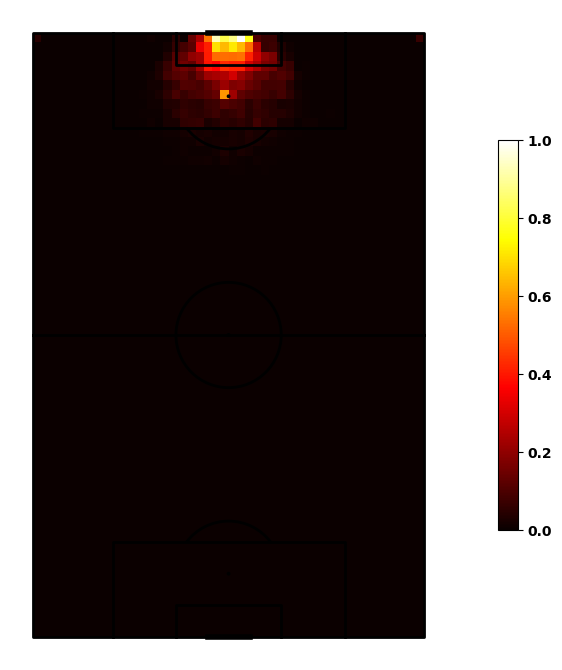

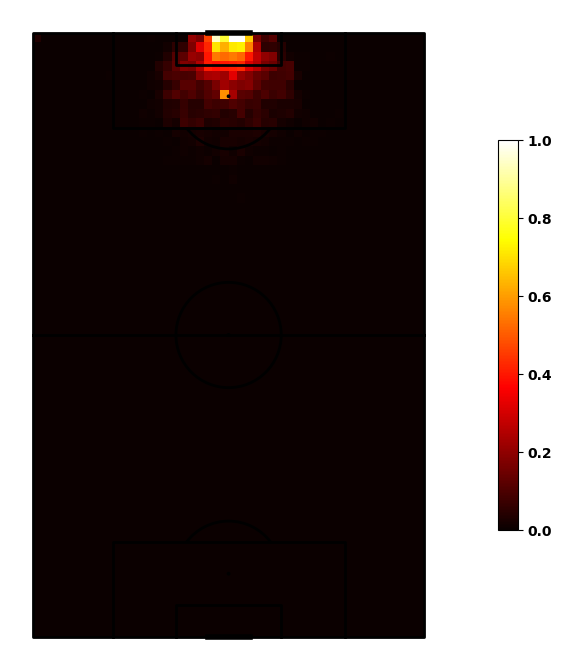

In [61]:
xT_true.plot_pitch_heatmap(xT_true.xG*xT_true.probability_shooting)
xT_sampled.plot_pitch_heatmap(xT_sampled.xG*xT_sampled.probability_shooting)